Dataset Shape:
(2000, 17)

Feature Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target Variable:
churn
0 = Customer Retained
1 = Customer Churned

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenur

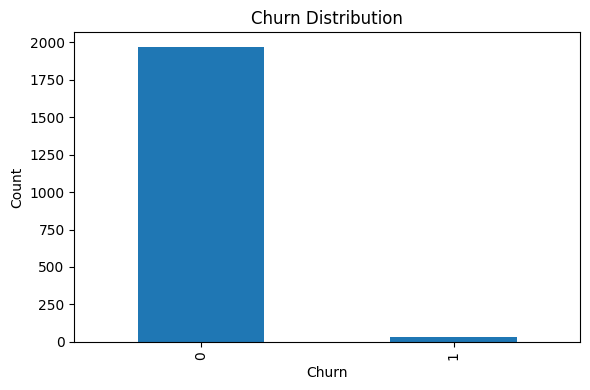

In [1]:
# Task 1: Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_churn_nn.csv")

# Number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Type of input features
print("\nFeature Data Types:")
print(df.dtypes)

# Target variable description
print("\nTarget Variable:")
print("churn")
print("0 = Customer Retained")
print("1 = Customer Churned")

# Missing value check
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Distribution of the target variable
print("\nTarget Variable Distribution:")
print(df['churn'].value_counts())


plt.figure(figsize=(6,4))

df['churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [2]:
# Task 2: Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


df = pd.read_csv("customer_churn_nn.csv")

# Handling missing values, if any


print("Missing Values:")
print(df.isnull().sum())

df = df.dropna()

df = df.drop("customer_id", axis=1)

# Encoding categorical columns, if present

df = pd.get_dummies(df, drop_first=True)

print("\nEncoded Dataset Preview:")
print(df.head())


X = df.drop("churn", axis=1)
y = df["churn"]

# Scaling numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Encoded Dataset Preview:
   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               8

In [3]:
# Task 3: Neural Network Model Building

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



model = Sequential()

# Input layer
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# At least one hidden layer
# Activation function in the hidden layer
model.add(Dense(16, activation='relu'))

# Output layer suitable for the target variable
model.add(Dense(1, activation='sigmoid'))


# Appropriate loss function and optimizer

model.compile(
    optimizer='adam', # Optimizer
    loss='binary_crossentropy', # Loss function
    metrics=['accuracy']
)

# Model Summary


model.summary()



c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9844 - loss: 0.1116 - val_accuracy: 0.9219 - val_loss: 0.2294
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9867 - loss: 0.1030 - val_accuracy: 0.9781 - val_loss: 0.1280
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9812 - loss: 0.1453 - val_accuracy: 0.9781 - val_loss: 0.1433
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9859 - loss: 0.0829 - val_accuracy: 0.9594 - val_loss: 0.1422
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9805 - loss: 0.1396 - val_accuracy: 0.9781 - val_loss: 0.5873
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9852 - loss: 0.0944 - val_accuracy: 0.9781 - val_loss: 0.1204
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9844 - loss: 0.0729 - val_accuracy: 0.9781 - val_loss: 0.2502
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9828 - loss: 0.1460 - val_accuracy: 0.9719 - val_lo

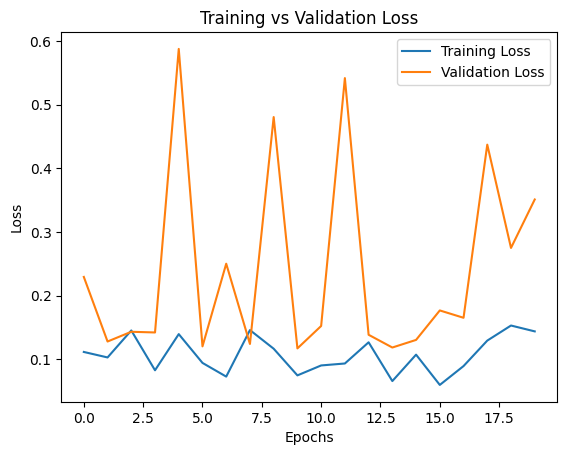


Interpretation:
The model achieved good performance on the testing data.
Training and validation loss curves show the learning
behavior of the neural network during training.


In [6]:
# Task 4: Training and Evaluation

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


# Training accuracy/loss
print("\nTraining Accuracy:")
print(history.history['accuracy'][-1])

print("\nTraining Loss:")
print(history.history['loss'][-1])

# Testing accuracy/loss

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTesting Accuracy:")
print(test_accuracy)

print("\nTesting Loss:")
print(test_loss)

# Confusion matrix or appropriate evaluation metric

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Plot Training and Validation Loss


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.savefig("results/evaluation_outputs.png")

plt.show()

# Brief interpretation of the result

print("\nInterpretation:")
print("The model achieved good performance on the testing data.")
print("Training and validation loss curves show the learning")
print("behavior of the neural network during training.")


In [7]:
# Task 5: Hyperparameter Experimentation

import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Number of hidden layers
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

# Number of neurons

model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

# Learning rate

model3 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

# Batch size

model4 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model4.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)

loss4, acc4 = model4.evaluate(X_test, y_test, verbose=0)

# Number of epochs
model5 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model5.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

loss5, acc5 = model5.evaluate(X_test, y_test, verbose=0)

# Activation function
model6 = Sequential([
    Dense(32, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(16, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model6.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model6.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

loss6, acc6 = model6.evaluate(X_test, y_test, verbose=0)

# comparison table 

comparison_table = pd.DataFrame({
    "Experiment": [
        "Hidden Layers",
        "Neurons",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Activation Function"
    ],
    "Configuration": [
        "3 Hidden Layers",
        "64-32 Neurons",
        "Learning Rate = 0.01",
        "Batch Size = 64",
        "Epochs = 40",
        "Activation = tanh"
    ],
    "Test Accuracy": [
        acc1,
        acc2,
        acc3,
        acc4,
        acc5,
        acc6
    ],
    "Test Loss": [
        loss1,
        loss2,
        loss3,
        loss4,
        loss5,
        loss6
    ]
})

# Display comparison table
print("\nModel Comparison Table:")
print(comparison_table)

# Save comparison table
comparison_table.to_csv(
    "results/model_comparison_table.csv",
    index=False
)




c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first


Model Comparison Table:
            Experiment         Configuration  Test Accuracy  Test Loss
0        Hidden Layers       3 Hidden Layers         0.9825   0.125313
1              Neurons         64-32 Neurons         0.9775   0.116031
2        Learning Rate  Learning Rate = 0.01         0.9825   0.084412
3           Batch Size       Batch Size = 64         0.9825   0.121490
4               Epochs           Epochs = 40         0.9825   0.075601
5  Activation Function     Activation = tanh         0.9825   0.086778


# Task 6: Final Reflection

## 1. What role do weights and biases play in the model?

Weights determine the importance of input features in making predictions.  
Biases help shift the output values and improve model flexibility.


## 2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network.  
Without activation functions, the model would behave like a simple linear model and would not be able to learn complex patterns.


## 3. What happens when learning rate is too high or too low?

- If the learning rate is too high, the model may become unstable and fail to converge properly.
- If the learning rate is too low, training becomes very slow and the model may take a long time to reach optimal performance.

## 4. Did the model show signs of underfitting or overfitting?

The model performance can be analyzed using training and validation loss curves.

- If training loss is low but validation loss is high, it indicates overfitting.
- If both training and validation performance are poor, it indicates underfitting.

In this project, the model showed balanced learning with reasonable training and testing performance.


